<a href="https://colab.research.google.com/github/chetankhairnar05/Colab/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv("/content/Obesity Risk - Obesity Risk.csv")
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df.isnull().sum()

,0
id,0
Gender,1
Age,2
Height,2
Weight,16
family_history_with_overweight,15
FAVC,9
FCVC,5
NCP,6
CAEC,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20757 non-null  object 
 2   Age                             20756 non-null  float64
 3   Height                          20756 non-null  float64
 4   Weight                          20742 non-null  float64
 5   family_history_with_overweight  20743 non-null  object 
 6   FAVC                            20749 non-null  object 
 7   FCVC                            20753 non-null  float64
 8   NCP                             20752 non-null  float64
 9   CAEC                            20751 non-null  object 
 10  SMOKE                           20756 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [ ]:
#print unique values for all object datatypes for all columns
object_col = df.select_dtypes(include=['object']).columns.to_list()
for i in object_col:
  print(i,df[i].unique())


Gender ['Male' 'Female' nan]
family_history_with_overweight ['yes' 'no' nan]
FAVC ['yes' 'no' nan]
CAEC ['Sometimes' 'Frequently' nan 'Always' 'no']
SMOKE ['no' 'yes' nan]
SCC ['no' 'yes' nan]
CALC ['Sometimes' 'no' 'Frequently' nan]
MTRANS ['Public_Transportation' 'Automobile' 'Walking' nan 'Motorbike' 'Bike']
NObeyesdad ['Overweight_Level_II' 'Normal_Weight' 'Insufficient_Weight'
 'Obesity_Type_III' 'Obesity_Type_II' 'Overweight_Level_I'
 'Obesity_Type_I' nan]


In [ ]:
#drop all rows which has NObeyesdad  = nan
df = df.dropna(subset=['NObeyesdad'])

In [ ]:
df.isnull().sum()

,0
id,0
Gender,1
Age,2
Height,2
Weight,15
family_history_with_overweight,15
FAVC,7
FCVC,4
NCP,5
CAEC,7


In [ ]:
df = df.drop('id', axis=1)

In [ ]:
#impute non numnercal cols with most frequent values
from sklearn.impute import SimpleImputer

# Initialize imputer with 'most_frequent' strategy
imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform the object columns
df[object_col] = imputer.fit_transform(df[object_col])
df.isnull().sum()

,0
Gender,0
Age,2
Height,2
Weight,15
family_history_with_overweight,0
FAVC,0
FCVC,4
NCP,5
CAEC,0
SMOKE,0


In [ ]:
#K-Means Imputation for numerical values
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Get numerical columns
num_cols = df.select_dtypes(include=['number']).columns

# 2. Temporary fill & Scaling
df_temp = df[num_cols].fillna(df[num_cols].mean())
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_temp)

# 3. Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled)

# 4. Impute missing values using cluster means
for col in num_cols:
    cluster_means = df.groupby('cluster')[col].transform('mean')
    df[col] = df[col].fillna(cluster_means)

df.drop(columns=['cluster'], inplace=True)
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20751 entries, 0 to 20757
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          20751 non-null  object 
 1   Age                             20751 non-null  float64
 2   Height                          20751 non-null  float64
 3   Weight                          20751 non-null  float64
 4   family_history_with_overweight  20751 non-null  object 
 5   FAVC                            20751 non-null  object 
 6   FCVC                            20751 non-null  float64
 7   NCP                             20751 non-null  float64
 8   CAEC                            20751 non-null  object 
 9   SMOKE                           20751 non-null  object 
 10  CH2O                            20751 non-null  float64
 11  SCC                             20751 non-null  object 
 12  FAF                             20751

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20751.000000,20751.000000,20751.000000,20751.000000,20751.000000,20751.000000,20751.000000,20751.000000
mean,23.842153,1.700260,87.893099,2.445792,2.761158,2.029369,0.981862,0.616755
std,5.688275,0.087314,26.374417,0.533156,0.705407,0.608529,0.838278,0.602100
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,22.815416,1.700000,84.124993,2.393837,3.000000,2.000000,1.000000,0.573887
75%,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


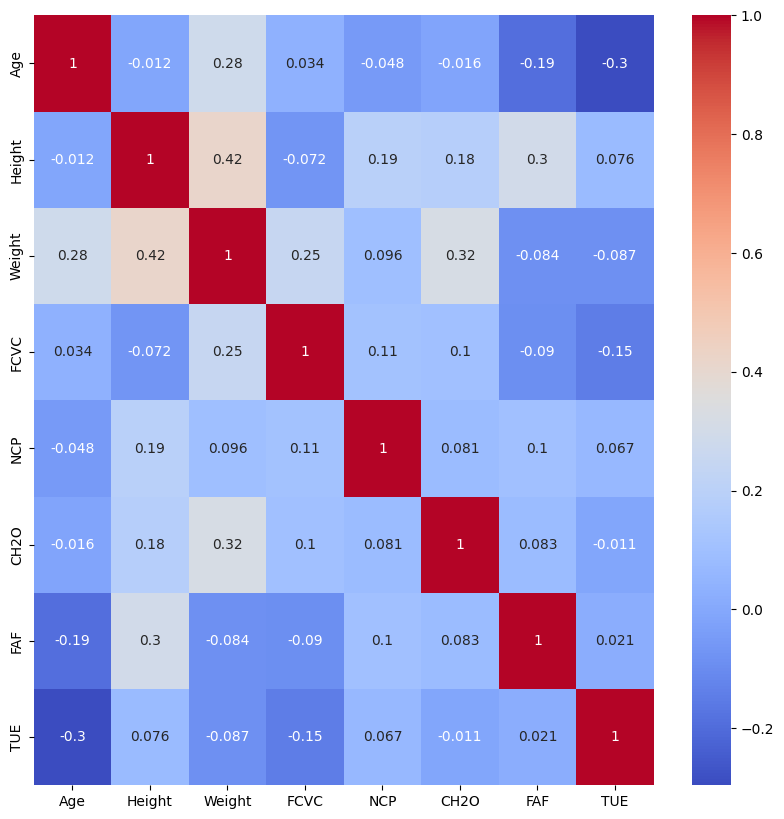

In [ ]:
#heatmap of correlation of numerical dtypes
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [ ]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20751 entries, 0 to 20757
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          20751 non-null  object 
 1   Age                             20751 non-null  float64
 2   Height                          20751 non-null  float64
 3   Weight                          20751 non-null  float64
 4   family_history_with_overweight  20751 non-null  object 
 5   FAVC                            20751 non-null  object 
 6   FCVC                            20751 non-null  float64
 7   NCP                             20751 non-null  float64
 8   CAEC                            20751 non-null  object 
 9   SMOKE                           20751 non-null  object 
 10  CH2O                            20751 non-null  float64
 11  SCC                             20751 non-null  object 
 12  FAF                             20751

In [ ]:
#print unique values for all object datatypes for all columns
object_col = df.select_dtypes(include=['object']).columns.to_list()
for i in object_col:
  print(i,df[i].unique())


Gender ['Male' 'Female']
family_history_with_overweight ['yes' 'no']
FAVC ['yes' 'no']
CAEC ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE ['no' 'yes']
SCC ['no' 'yes']
CALC ['Sometimes' 'no' 'Frequently']
MTRANS ['Public_Transportation' 'Automobile' 'Walking' 'Motorbike' 'Bike']
NObeyesdad ['Overweight_Level_II' 'Normal_Weight' 'Insufficient_Weight'
 'Obesity_Type_III' 'Obesity_Type_II' 'Overweight_Level_I'
 'Obesity_Type_I']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
le = LabelEncoder()

# 2. Transform the column and overwrite the original column in the dataframe
df['CAEC'] = le.fit_transform(df['CAEC'])
df['CALC'] = le.fit_transform(df['MTRANS'])
df['MTRANS'] = le.fit_transform(df['MTRANS'])



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20751 entries, 0 to 20757
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          20751 non-null  object 
 1   Age                             20751 non-null  float64
 2   Height                          20751 non-null  float64
 3   Weight                          20751 non-null  float64
 4   family_history_with_overweight  20751 non-null  object 
 5   FAVC                            20751 non-null  object 
 6   FCVC                            20751 non-null  float64
 7   NCP                             20751 non-null  float64
 8   CAEC                            20751 non-null  int64  
 9   SMOKE                           20751 non-null  object 
 10  CH2O                            20751 non-null  float64
 11  SCC                             20751 non-null  object 
 12  FAF                             20751

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Assuming your loaded dataframe is named 'df'

# ---------------------------------------------------------
# Step 1: Separate Features (X) and Target (y)
# 'NObeyesdad' is the target variable (Obesity level)
# ---------------------------------------------------------
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# ---------------------------------------------------------
# Step 2: Encode Categorical Variables
# ---------------------------------------------------------
# 2a. Convert feature 'object' columns to numerical using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 2b. Encode the target variable into integers (0, 1, 2, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ---------------------------------------------------------
# Step 3: Train-Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ---------------------------------------------------------
# Step 4: Initialize the Classifier
# ---------------------------------------------------------
dtree_clf = DecisionTreeClassifier(random_state=42)

# ---------------------------------------------------------
# Step 5: Define the Hyperparameter Grid for Classification
# ---------------------------------------------------------
param_grid = {
    'criterion': ['gini', 'entropy'],           # Measure of split quality
    'splitter': ['best', 'random'],             # Strategy to choose the split
    'max_depth': [None,5, 10],            # Maximum depth of the tree
    'min_samples_split': [2, 5],        # Minimum samples required to split a node
    'min_samples_leaf': [1, 3,7],          # Minimum samples required at a leaf node
    'max_features': [ 'sqrt', 'log2'],     # Number of features to consider for best split

}

# ---------------------------------------------------------
# Step 6: Set up and Run GridSearchCV
# ---------------------------------------------------------
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all available CPU cores to speed up training
grid_search = GridSearchCV(
    estimator=dtree_clf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy' # You can change this to 'f1_weighted' if classes are highly imbalanced
)

# Fit the grid search to the training data
print("Starting Grid Search... This may take a few minutes.")
grid_search.fit(X_train, y_train)

# ---------------------------------------------------------
# Step 7: Evaluate the Best Model
# ---------------------------------------------------------
best_dtree = grid_search.best_estimator_
y_pred = best_dtree.predict(X_test)

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Print a detailed classification report mapping back to original text labels
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Starting Grid Search... This may take a few minutes.
Fitting 5 folds for each of 144 candidates, totalling 720 fits

--- Grid Search Results ---
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'splitter': 'best'}
Test Accuracy: 0.8429

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.88      0.87       505
      Normal_Weight       0.78      0.82      0.80       616
     Obesity_Type_I       0.81      0.81      0.81       582
    Obesity_Type_II       0.93      0.94      0.94       650
   Obesity_Type_III       0.99      0.99      0.99       809
 Overweight_Level_I       0.70      0.66      0.68       485
Overweight_Level_II       0.71      0.69      0.70       504

           accuracy                           0.84      4151
          macro avg       0.83      0.83      0.83      4151
       weighted avg       0.84      0.84     

In [ ]:
# from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 6],
    'min_samples_leaf': [1, 2],

}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_dtree = grid_search.best_estimator_
y_pred = best_dtree.predict(X_test)

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Print a detailed classification report mapping back to original text labels
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


--- Grid Search Results ---
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 200}
Test Accuracy: 0.9000

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.92      0.93       505
      Normal_Weight       0.85      0.90      0.87       616
     Obesity_Type_I       0.87      0.89      0.88       582
    Obesity_Type_II       0.96      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.82      0.73      0.78       485
Overweight_Level_II       0.79      0.81      0.80       504

           accuracy                           0.90      4151
          macro avg       0.89      0.89      0.89      4151
       weighted avg       0.90      0.90      0.90      4151

